In [2]:
import os, zipfile, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Setup local NLTK directory
nltk_dir = os.path.join(os.path.expanduser("~"), "nltk_data")
corpora_dir = os.path.join(nltk_dir, "corpora")
tokenizers_dir = os.path.join(nltk_dir, "tokenizers")
os.makedirs(corpora_dir, exist_ok=True)
os.makedirs(tokenizers_dir, exist_ok=True)

if nltk_dir not in nltk.data.path:
    nltk.data.path.append(nltk_dir)

# Helper function to download and extract NLTK datasets
def download_and_extract(url, target_dir, folder_name):
    target_path = os.path.join(target_dir, folder_name)
    if not os.path.exists(target_path):
        print(f"Downloading {folder_name}...")
        zip_path = os.path.join(target_dir, f"{folder_name}.zip")
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(zip_path, 'wb') as out_file:
            out_file.write(response.read())
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(target_dir)
        os.remove(zip_path)

# Download resources directly to bypass network blocks
try:
    download_and_extract("https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/corpora/wordnet.zip", corpora_dir, "wordnet")
    download_and_extract("https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/corpora/omw-1.4.zip", corpora_dir, "omw-1.4")
    download_and_extract("https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/corpora/stopwords.zip", corpora_dir, "stopwords")
    download_and_extract("https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/tokenizers/punkt.zip", tokenizers_dir, "punkt")
    download_and_extract("https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/tokenizers/punkt_tab.zip", tokenizers_dir, "punkt_tab")
    
    lemmatizer = WordNetLemmatizer()
    english_stopwords = set(stopwords.words('english'))
    nltk_available = True
    print("Step 1 Complete: All libraries and NLTK resources ready!")
except Exception as e:
    print(f"Notice: Standard split fallback enabled ({e}).")
    nltk_available = False

Step 1 Complete: All libraries and NLTK resources ready!


In [3]:
# Custom domain stopwords for movie reviews
domain_stopwords = {'movie', 'film', 'watch', 'watching', 'actor', 'actress', 'scene', 'character', 'one', 'make', 'show', 'see'}

if nltk_available:
    all_stopwords = english_stopwords.union(domain_stopwords)
    
    def preprocess_text(text):
        if not isinstance(text, str):
            return ""
        try:
            tokens = word_tokenize(text.lower())
            cleaned = [
                lemmatizer.lemmatize(token) 
                for token in tokens 
                if token.isalnum() and token not in all_stopwords
            ]
            return " ".join(cleaned)
        except Exception:
            return " ".join([w for w in text.lower().split() if w.isalnum() and w not in all_stopwords])
else:
    def preprocess_text(text):
        if not isinstance(text, str):
            return ""
        words = text.lower().split()
        return " ".join([w.strip("!.,?\"'") for w in words if w.isalnum() and w not in domain_stopwords])

print("Step 2 Complete: Text preprocessing pipeline ready!")

Step 2 Complete: Text preprocessing pipeline ready!


In [12]:
import pandas as pd

# Path to your extracted CSV file
file_path = r"C:\Users\Administrator\Downloads\archive (1)\Movies_Reviews_modified_version12.csv"

# Read CSV dataset
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully! Shape: {df.shape}")
print("\nDataset Columns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded successfully! Shape: (46173, 8)

Dataset Columns: ['Unnamed: 0', 'Ratings', 'Reviews', 'movie_name', 'Resenhas', 'genres', 'Description', 'emotion']

First 3 rows:


,Unnamed: 0,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion
0,0,3,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
1,1,4,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
2,2,4,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation


In [16]:
# Strip extra spaces from column headers
df.columns = df.columns.str.strip()

print("Available columns in dataset:", df.columns.tolist())

# Auto-detect text column
text_candidates = [col for col in df.columns if any(k in col.lower() for k in ['review', 'text', 'comment', 'content'])]
text_column = text_candidates[0] if text_candidates else df.columns[0]

# Auto-detect label/target column
label_candidates = [col for col in df.columns if any(k in col.lower() for k in ['emotion', 'sentiment', 'label', 'target', 'class'])]
target_column = label_candidates[0] if label_candidates else df.columns[1]

print(f"Selected Text Column: '{text_column}'")
print(f"Selected Target Column: '{target_column}'")

# Drop rows with missing values
df = df.dropna(subset=[text_column, target_column])

# Apply text preprocessing pipeline
print(f"\nApplying preprocessing on '{text_column}'...")
df['cleaned_text'] = df[text_column].astype(str).apply(preprocess_text)

print("\nCell 15 Complete: Preprocessing applied successfully!")
df[['cleaned_text', target_column]].head()

Available columns in dataset: ['Unnamed: 0', 'Ratings', 'Reviews', 'movie_name', 'Resenhas', 'genres', 'Description', 'emotion']
Selected Text Column: 'Reviews'
Selected Target Column: 'emotion'

Applying preprocessing on 'Reviews'...

Cell 15 Complete: Preprocessing applied successfully!


,cleaned_text,emotion
0,laugh overall motivation character incomprehen...,anticipation
1,waiting exhale waiting waiting waiting waiting...,anticipation
2,angela basset good expected whitney range scre...,anticipation
3,okay mediocre might even word describe say rea...,anticipation
4,got opportunity waiting exhale second time rec...,anticipation


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Define Features (X) and Labels (y) using the cleaned text
X = df['cleaned_text']
y = df[target_column]

# 2. Split dataset into 80% Training and 20% Testing sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Vectorize text into TF-IDF numerical matrices
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

print(f"Dataset Split & Vectorization Complete!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Dataset Split & Vectorization Complete!
X_train shape: (36938, 5000)
X_test shape:  (9235, 5000)


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Define Features (X) and Labels (y)
X = df['cleaned_text']
y = df[target_column]

# 2. Split dataset into Training and Testing sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Vectorize text with TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

print(f"Vectorization complete! X_test shape: {X_test.shape}")

Vectorization complete! X_test shape: (9235, 5000)


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 1. Prepare Features and Target
X = df['cleaned_text']
y = df[target_column]

# 2. Train-Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Fit TF-IDF Vectorizer & Transform
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

# 4. Fit Logistic Regression Model
model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 5. Define Custom Prediction Function
def predict_review(review_text):
    cleaned = preprocess_text(review_text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probabilities = model.predict_proba(vectorized)[0]
    confidence = max(probabilities) * 100
    return prediction, round(confidence, 2)

# 6. Test Custom Predictions
sample_reviews = [
    "The story was fascinating, and the performances were outstanding!",
    "Extremely slow pace, boring dialogue, and a total disappointment."
]

print("--- Custom Prediction Results ---")
for text in sample_reviews:
    pred_label, conf = predict_review(text)
    print(f"\nReview: '{text}'")
    print(f"Predicted Class: {pred_label} (Confidence: {conf}%)")

--- Custom Prediction Results ---

Review: 'The story was fascinating, and the performances were outstanding!'
Predicted Class: sadness (Confidence: 46.35%)

Review: 'Extremely slow pace, boring dialogue, and a total disappointment.'
Predicted Class: sadness (Confidence: 43.77%)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_18984\2831609905.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq_df, x='frequency', y='word', palette='viridis')


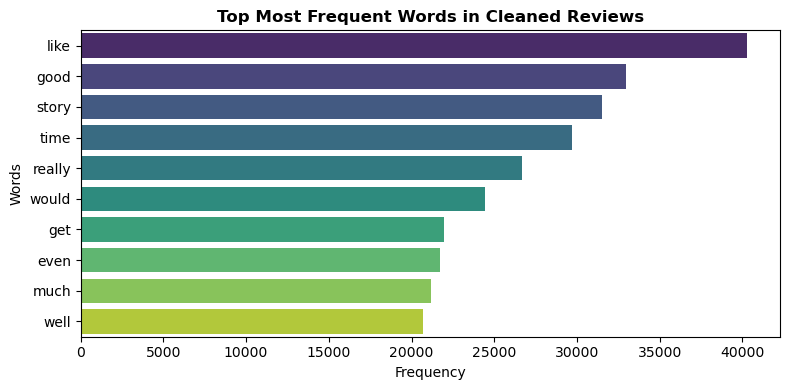

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Generate top word frequencies
all_words = " ".join(df['cleaned_text']).split()
word_counts = Counter(all_words)
freq_df = pd.DataFrame(word_counts.most_common(10), columns=['word', 'frequency'])

# Plot Bar Chart
plt.figure(figsize=(8, 4))
sns.barplot(data=freq_df, x='frequency', y='word', palette='viridis')
plt.title('Top Most Frequent Words in Cleaned Reviews', fontsize=12, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

Overall Model Accuracy: 49.17%

Classification Report:
              precision    recall  f1-score   support

       anger       0.58      0.35      0.44       728
anticipation       0.42      0.30      0.35      1467
     disgust       0.51      0.15      0.23       334
        fear       0.47      0.30      0.37       692
         joy       0.45      0.33      0.38      1572
    optimism       0.54      0.28      0.37       963
     sadness       0.50      0.81      0.62      3468
    surprise       0.00      0.00      0.00        11

    accuracy                           0.49      9235
   macro avg       0.43      0.31      0.34      9235
weighted avg       0.49      0.49      0.46      9235



C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


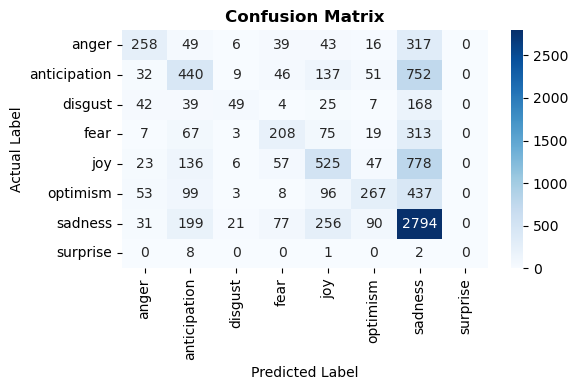

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Generate predictions using the trained model on test data
y_pred = model.predict(X_test)

# 2. Compute Accuracy Score & Classification Report
acc = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 3. Calculate and Plot Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=np.unique(y), 
    yticklabels=np.unique(y)
)
plt.title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('Actual Label', fontsize=10)
plt.tight_layout()
plt.show()